# Figure 3 — Order effects in higher-order discriminability

This notebook generates **Figure 3** of the paper:
- **Panels a–d**: Ω boxplots per order for the best n-plets (C vs NR macrostates).
- **Panels e–f**: PR-AUC vs order line plots comparing $\Omega$ (HOI) against pairwise FC.

**Inputs** (from `results/`):
- `R1_B_nplet_eval_MA.csv` and `R1_B_nplet_eval_DBS.csv` — per-n-plet LOPO PR-AUC scores
  (produced by `R1_A_lopo.ipynb`).

**Parameter**: Set `N_TOP = 1` for Fig 3 (single best n-plet per order/polarity);
set `N_TOP = 50` for the robustness check in Supplementary `S3_order_robustness.ipynb`.

In [1]:
from pathlib import Path
import os

def ensure_project_root(target_name: str = "high-order-anesthesia") -> Path:
    cwd = Path.cwd().resolve()
    if cwd.name == target_name:
        return cwd
    for parent in cwd.parents:
        if parent.name == target_name:
            os.chdir(parent)
            return parent
    raise RuntimeError(f"Could not find '{target_name}' in path.")

ROOT = ensure_project_root()
print(f"Now in: {ROOT.name}")

Now in: high-order-anesthesia


In [2]:
import logging
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from ast import literal_eval
from thoi.measures.gaussian_copula import nplets_measures

In [3]:
from src.hoi_anesthesia.io import load_covariance_dict

## Configuration

In [4]:
results_path = "results"
data_path    = "data"
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_TOP     = 1    # top n-plets per (order, polarity). Use 50 for the robustness check.
FONTSIZE  = 12
LWIDTH    = 2
MSIZE     = 7

HOI_MEASURE = "O"
PW_MEASURE  = "FC_mean_z"

plt.rcParams.update({"font.size": FONTSIZE})
sns.set_theme(style="white")

all_covs = load_covariance_dict(f"{data_path}/covariance_matrices_gc.h5")

## Helper utilities

In [5]:
def to_nplet_tuple(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return tuple(int(i) for i in x)
    if isinstance(x, str):
        return tuple(int(i) for i in literal_eval(x))
    raise TypeError(f"Unexpected type for optimal_nplet: {type(x)}")

def build_X_for_dataset(dataset: str, all_covs):
    """Build the stacked covariance tensor (C scans first, then NR scans)."""
    if dataset == "MA":
        conscious_states     = {"MA": ["MA_awake"]}
        nonresponsive_states = {"MA": ["deep_propofol", "ketamine",
                                        "moderate_propofol", "ts_selv2", "ts_selv4"]}
    elif dataset == "DBS":
        conscious_states     = {"DBS": ["DBS_awake", "ts_on_5V"]}
        nonresponsive_states = {"DBS": ["ts_off", "ts_on_3V_control", "ts_on_5V_control"]}
    else:
        raise ValueError(f"Unknown dataset: {dataset}")

    rows_c, rows_nr = [], []
    for ds, states in conscious_states.items():
        for st in states:
            rows_c.extend(all_covs[ds][st])
    for ds, states in nonresponsive_states.items():
        for st in states:
            rows_nr.extend(all_covs[ds][st])

    X = torch.tensor(np.array(rows_c + rows_nr))
    return X, len(rows_c), len(rows_nr)

---
## Step 1 — Load evaluation results and select top n-plets

In [10]:
# ── Load CSVs produced by R1_A_lopo.ipynb ────────────────────────────────────
# Saved with sep=";", decimal=","
# The "polarity" column uses 'c_gt_nr' (Omega_C > Omega_NR)
# and 'nr_gt_c' (Omega_NR > Omega_C).
nplet_eval = {}
for dataset in ["MA", "DBS"]:
    df = pd.read_csv(
        f"{results_path}/R1_A_nplet_eval_{dataset}.csv",
        sep=";", decimal=",", encoding="utf-8-sig",
    )
    df = df.query("measure in ['O', 'FC_mean_z']")
    df["nplet"] = df["optimal_nplet"].apply(to_nplet_tuple)
    nplet_eval[dataset] = df

print("Columns:", nplet_eval["MA"].columns.tolist())
nplet_eval["MA"].head()


Columns: ['order', 'polarity', 'state_c', 'state_nr', 'subject_c', 'subject_nr', 'optimal_nplet', 'optimal_score', 'measure', 'F_score', 'PR_AUC', 'PR_AUC_inv', 'nplet']


,order,polarity,state_c,state_nr,subject_c,subject_nr,optimal_nplet,optimal_score,measure,F_score,PR_AUC,PR_AUC_inv,nplet
2,2,c_gt_nr,MA_awake,ts_selv2,0,0,"[42, 72]",8.881784e-16,O,0.000000,0.211039,0.196021,"(42, 72)"
5,2,c_gt_nr,MA_awake,ts_selv2,0,0,"[42, 72]",8.881784e-16,FC_mean_z,23.193982,0.517949,0.131781,"(42, 72)"
8,2,c_gt_nr,MA_awake,ts_selv2,0,1,"[43, 69]",8.881784e-16,O,0.000000,0.180566,0.219120,"(43, 69)"
11,2,c_gt_nr,MA_awake,ts_selv2,0,1,"[43, 69]",8.881784e-16,FC_mean_z,26.786257,0.620802,0.135406,"(43, 69)"
14,2,c_gt_nr,MA_awake,ts_selv2,0,2,"[2, 61]",8.881784e-16,O,0.000000,0.227540,0.182152,"(2, 61)"


In [11]:
# ── Aggregate over LOPO folds (mean PR-AUC) ──────────────────────────────────
agg_cols   = ["F_score", "PR_AUC", "PR_AUC_inv"]
group_cols = ["order", "polarity", "measure", "nplet"]

df_agg = {ds: df.groupby(group_cols, as_index=False)[agg_cols].mean()
          for ds, df in nplet_eval.items()}

# ── Signed PR-AUC: c_gt_nr uses PR_AUC, nr_gt_c uses PR_AUC_inv ─────────────
for ds, df in df_agg.items():
    df["PR_AUC_signed"] = np.where(
        df["polarity"] == "c_gt_nr", df["PR_AUC"], df["PR_AUC_inv"]
    )


In [13]:
# ── Select top-N_TOP n-plets per (order, polarity) based on Ω ────────────────
top_nplets_dict = {}  # {(dataset, order, polarity): [nplet_tuples]}
df_top_list     = []

for dataset, df in df_agg.items():
    df_O = df[(df["measure"] == HOI_MEASURE) & df["order"].between(3, 9)].copy()
    df_O_sorted = df_O.sort_values(
        ["order", "polarity", "PR_AUC_signed"], ascending=[True, True, False]
    )
    top_O = df_O_sorted.groupby(["order", "polarity"]).head(N_TOP).reset_index(drop=True)

    for (k, polarity), sub in top_O.groupby(["order", "polarity"]):
        top_nplets_dict[(dataset, k, polarity)] = list(sub["nplet"])

    selected = top_O[["order", "polarity", "nplet"]].drop_duplicates()
    df_full  = df.merge(selected, on=["order", "polarity", "nplet"], how="inner")
    df_full["dataset"] = dataset
    df_top_list.append(df_full)

df_top_all = pd.concat(df_top_list, ignore_index=True)
print(f"N_TOP={N_TOP} | top_nplets_dict has {len(top_nplets_dict)} entries")
print(df_top_all.head())


N_TOP=1 | top_nplets_dict has 28 entries
   order polarity    measure             nplet     F_score    PR_AUC  \
0      3  c_gt_nr  FC_mean_z      (28, 39, 72)  160.094288  0.977814   
1      3  c_gt_nr          O      (28, 39, 72)  156.335522  0.972403   
2      3  nr_gt_c  FC_mean_z      (23, 34, 81)    7.148606  0.165519   
3      3  nr_gt_c          O      (23, 34, 81)  159.159814  0.111550   
4      4  c_gt_nr  FC_mean_z  (11, 14, 23, 55)  247.508366  0.964255   

   PR_AUC_inv  PR_AUC_signed dataset  
0    0.109840       0.977814      MA  
1    0.109869       0.972403      MA  
2    0.394630       0.394630      MA  
3    0.943832       0.943832      MA  
4    0.109944       0.964255      MA  


---
## Step 2 — Compute Ω for top n-plets across all C / NR scans

For each dataset we stack all conscious scans first, then non-responsive scans,
so that macrostate labels can be inferred from position.

In [17]:
rows_box = []

for dataset in ["MA", "DBS"]:
    # print(f"\n=== {dataset} ===")
    X_tensor, n_c, n_nr = build_X_for_dataset(dataset, all_covs)
    X_tensor = X_tensor.to(device=device, dtype=torch.float64)
    N_subjects = X_tensor.shape[0]

    for polarity in ["c_gt_nr", "nr_gt_c"]:
        for order in range(3, 10):
            key     = (dataset, order, polarity)
            nplets  = top_nplets_dict.get(key, [])
            if not nplets:
                continue

            # print(f"  {polarity}, order {order}: {len(nplets)} n-plet(s)")
            nplets_tensor = torch.tensor(nplets, dtype=torch.long, device=device)

            measures = nplets_measures(
                X=X_tensor,
                covmat_precomputed=True,
                nplets=nplets_tensor,
                device=device,
                verbose=logging.WARNING,
            )
            # shape: (B, N_subjects, n_measures) or (N_subjects, B, n_measures)
            if measures.shape[0] != N_subjects:
                measures_np = measures.detach().cpu().numpy().transpose(1, 0, 2)
            else:
                measures_np = measures.detach().cpu().numpy()

            O_vals = measures_np[:, :, 2]  # Ω index

            for s in range(N_subjects):
                macrostate = "C" if s < n_c else "NR"
                for j in range(O_vals.shape[1]):
                    rows_box.append({
                        "dataset":    dataset,
                        "polarity":   polarity,
                        "order":      order,
                        "subject":    s,
                        "macrostate": macrostate,
                        "value":      float(O_vals[s, j]),
                    })

df_box = pd.DataFrame(rows_box)


---
## Step 3 — Figure 3a–d: Ω boxplots per order

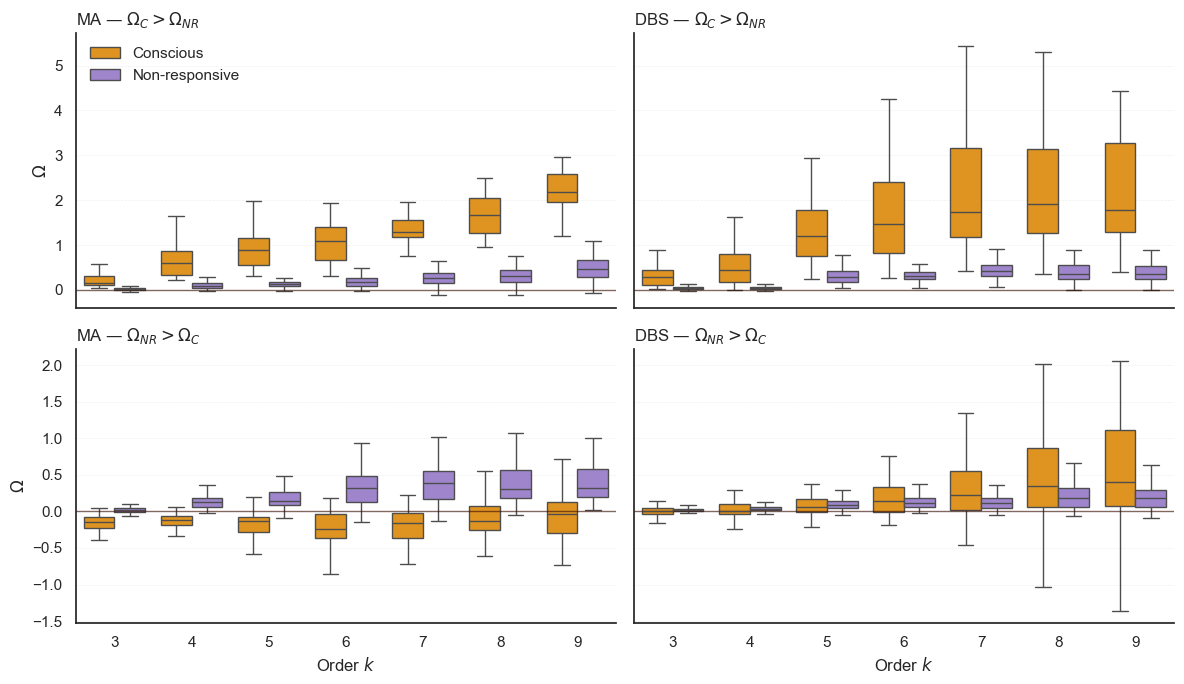

In [18]:
macro_palette = {
    "C":  "#FF9900",   # conscious
    "NR": "#9C7AD8",   # non-responsive
}
polarity_labels = {
    "c_gt_nr": r"$\Omega_C > \Omega_{NR}$",
    "nr_gt_c": r"$\Omega_{NR} > \Omega_C$",
}

scenarios = [
    ("MA",  "c_gt_nr", f"MA — {polarity_labels['c_gt_nr']}"),
    ("DBS", "c_gt_nr", f"DBS — {polarity_labels['c_gt_nr']}"),
    ("MA",  "nr_gt_c", f"MA — {polarity_labels['nr_gt_c']}"),
    ("DBS", "nr_gt_c", f"DBS — {polarity_labels['nr_gt_c']}"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey="row")
axes = axes.ravel()

for ax, (dataset, polarity, title) in zip(axes, scenarios):
    df_sub = df_box[
        (df_box["dataset"]  == dataset) &
        (df_box["polarity"] == polarity) &
        (df_box["order"].between(3, 9))
    ]
    if df_sub.empty:
        ax.set_visible(False)
        continue

    sns.boxplot(
        data=df_sub, x="order", y="value", hue="macrostate",
        palette=macro_palette, showfliers=False, ax=ax,
    )
    ax.axhline(0, color="#3A0F049E", linewidth=1)
    ax.set_title(title, fontsize=FONTSIZE, loc="left")
    ax.set_xlabel("Order $k$")
    ax.set_ylabel(r"$\Omega$" if dataset == "MA" else "")
    ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
    sns.despine(ax=ax)
    if ax is not axes[0]:
        ax.get_legend().remove()

handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ["Conscious", "Non-responsive"], frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig(f"results/fig3_boxplots_N{N_TOP}.pdf", bbox_inches="tight")
plt.show()

---
## Step 4 — Figure 3e–f: PR-AUC vs order (HOI vs pairwise FC)

In [19]:
# PR-AUC summary (mean ± 95% CI) per (dataset, measure, polarity, order)
summary = (
    df_top_all[df_top_all["order"].between(3, 9)]
    .groupby(["dataset", "measure", "polarity", "order"])["PR_AUC_signed"]
    .agg(["mean", "sem"])
    .reset_index()
)
summary["ci95"] = 1.96 * summary["sem"]
print(summary.head())


  dataset    measure polarity  order      mean  sem  ci95
0     DBS  FC_mean_z  c_gt_nr      3  0.937379  NaN   NaN
1     DBS  FC_mean_z  c_gt_nr      4  0.947544  NaN   NaN
2     DBS  FC_mean_z  c_gt_nr      5  0.939981  NaN   NaN
3     DBS  FC_mean_z  c_gt_nr      6  0.950057  NaN   NaN
4     DBS  FC_mean_z  c_gt_nr      7  0.948787  NaN   NaN


C:\Users\camil\AppData\Local\Temp\ipykernel_25852\1511202443.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vir           = cm.get_cmap("magma")


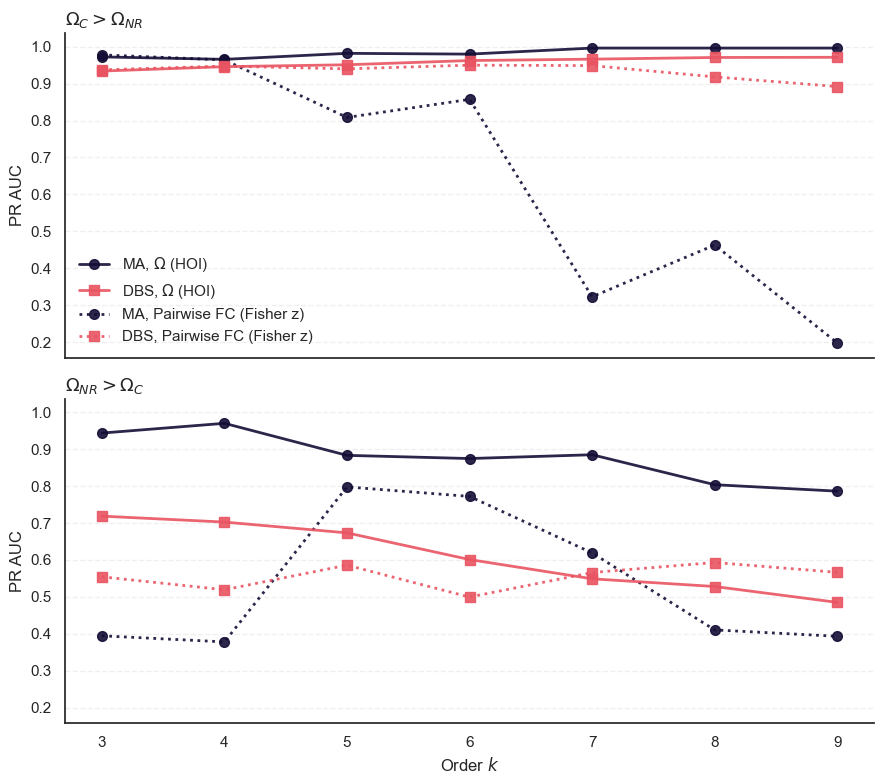

In [20]:
vir           = cm.get_cmap("magma")
colors        = vir(np.linspace(0.1, 0.9, 4))
color_dataset = {"MA": colors[0], "DBS": colors[2]}
ls_measure    = {"O": "-", "FC_mean_z": ":"}
mk_dataset    = {"MA": "o", "DBS": "s"}
measure_label = {"O": r"$\Omega$ (HOI)", "FC_mean_z": "Pairwise FC (Fisher z)"}

polarity_title = {
    "c_gt_nr": r"$\Omega_C > \Omega_{NR}$",
    "nr_gt_c": r"$\Omega_{NR} > \Omega_C$",
}

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, sharey=True)
legend_entries = {}

for ax, polarity in zip(axes, ["c_gt_nr", "nr_gt_c"]):
    for dataset in ["MA", "DBS"]:
        for measure in ["O", "FC_mean_z"]:
            sub = summary[
                (summary["dataset"]  == dataset) &
                (summary["measure"]  == measure) &
                (summary["polarity"] == polarity)
            ]
            if sub.empty:
                continue
            h = ax.errorbar(
                sub["order"], sub["mean"], yerr=sub["ci95"],
                color=color_dataset[dataset], linestyle=ls_measure[measure],
                marker=mk_dataset[dataset], markersize=MSIZE, linewidth=LWIDTH,
                capsize=3, alpha=0.9,
            )
            legend_entries[(dataset, measure)] = h[0]

    ax.set_title(polarity_title[polarity], loc="left", fontsize=FONTSIZE + 1)
    ax.set_ylabel("PR AUC")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    sns.despine(ax=ax)

axes[1].set_xlabel("Order $k$")

handles = [legend_entries[(ds, m)] for m in ["O", "FC_mean_z"] for ds in ["MA", "DBS"]
           if (ds, m) in legend_entries]
lbls    = [f"{ds}, {measure_label[m]}" for m in ["O", "FC_mean_z"] for ds in ["MA", "DBS"]
           if (ds, m) in legend_entries]
axes[0].legend(handles, lbls, frameon=False, fontsize=FONTSIZE - 1)

plt.tight_layout()
plt.savefig(f"results/fig3_PRAUC_lines_N{N_TOP}.pdf", bbox_inches="tight")
plt.show()
